In [1378]:
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from y0.algorithm.ioscm.utils import get_apt_order
from y0.graph import NxMixedGraph


In [1379]:
graphml_path = "../ecoli_full_network_no_small_rna.graphml"

In [1380]:
g = nx.read_graphml(graphml_path)

In [1381]:
total_nodes = len(g.nodes)
total_edges = len(g.edges)
total_nodes, total_edges

(2976, 9211)

In [1382]:
out_degree = dict(g.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(g.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(g.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [1383]:
out_degree_list[:20]

[('rpoD', 1662),
 ('crp', 559),
 ('nac', 529),
 ('lrp', 361),
 ('rpoS', 328),
 ('fnr', 320),
 ('fis', 245),
 ('arcA', 231),
 ('ihfA', 227),
 ('ihfB', 227),
 ('hns', 224),
 ('fur', 207),
 ('rpoH', 172),
 ('dksA', 156),
 ('rpoN', 142),
 ('rpoE', 126),
 ('narL', 124),
 ('cpxR', 122),
 ('glaR', 120),
 ('flhC', 92)]

In [1384]:
np.unique_counts(list(out_degree.values()))

UniqueCountsResult(values=array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   21,   22,   23,
         24,   26,   27,   28,   30,   32,   33,   37,   38,   42,   43,
         44,   46,   48,   49,   50,   51,   53,   56,   57,   61,   62,
         63,   72,   78,   85,   92,  120,  122,  124,  126,  142,  156,
        172,  207,  224,  227,  231,  245,  320,  328,  361,  529,  559,
       1662]), counts=array([2691,   23,   36,   30,   24,   16,   15,   12,   12,    9,   13,
          6,    7,    5,    6,    6,    1,    4,    2,    3,    1,    2,
          1,    1,    1,    1,    1,    2,    2,    1,    1,    1,    1,
          1,    1,    2,    1,    1,    1,    2,    1,    1,    1,    2,
          1,    1,    1,    1,    2,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    2,    1,    1,    1,    1,    1,    1,    1,
          1]))

In [1385]:
min(out_degree.values()), np.mean(list(out_degree.values())), np.median(list(out_degree.values())), max(out_degree.values())

(0, np.float64(3.0950940860215055), np.float64(0.0), 1662)

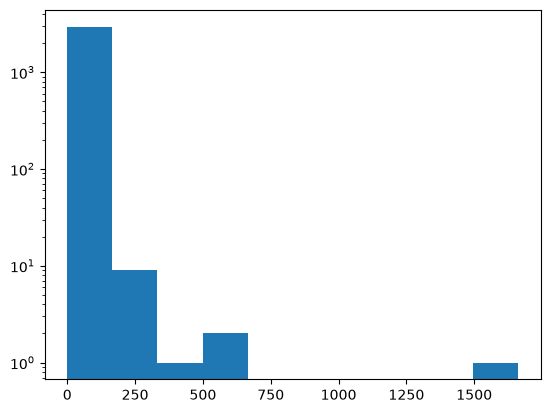

In [1386]:
plt.hist(list(out_degree.values()))
plt.yscale("log")

In [1387]:
in_degree_list[:20]

[('csgD', 20),
 ('csgE', 20),
 ('csgF', 20),
 ('csgG', 20),
 ('flhC', 17),
 ('flhD', 17),
 ('gadX', 17),
 ('gltF', 16),
 ('rsd', 15),
 ('gadW', 15),
 ('gadA', 14),
 ('gadB', 14),
 ('gltD', 14),
 ('gadE', 14),
 ('gltB', 13),
 ('rmf', 13),
 ('rpoE', 13),
 ('rseA', 13),
 ('fliA', 13),
 ('gadC', 12)]

In [1388]:
np.unique_counts(list(in_degree.values()))

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 20]), counts=array([ 54, 821, 671, 470, 315, 231, 143, 114,  54,  37,  23,  14,  10,
         5,   4,   2,   1,   3,   4]))

In [1389]:
min(in_degree.values()), np.mean(list(in_degree.values())), np.median(list(in_degree.values())), max(in_degree.values())

(0, np.float64(3.0950940860215055), np.float64(2.0), 20)

(array([ 875., 1141.,  546.,  257.,   91.,   37.,   15.,    6.,    4.,
           4.]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20.]),
 <BarContainer object of 10 artists>)

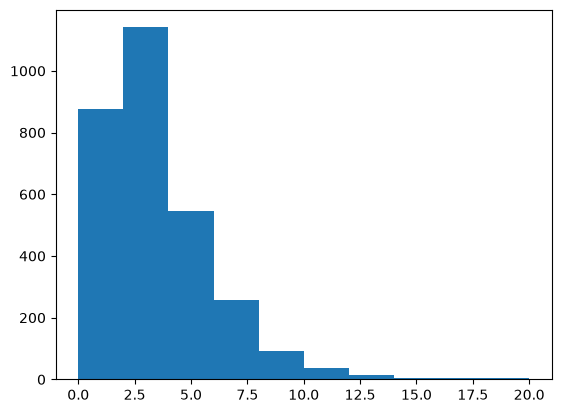

In [1390]:
plt.hist(list(in_degree.values()))

In [1391]:
degree_list[:20]

[('rpoD', 1667),
 ('crp', 563),
 ('nac', 535),
 ('lrp', 368),
 ('rpoS', 336),
 ('fnr', 326),
 ('fis', 252),
 ('arcA', 234),
 ('ihfA', 232),
 ('ihfB', 232),
 ('hns', 229),
 ('fur', 212),
 ('rpoH', 183),
 ('dksA', 159),
 ('rpoN', 145),
 ('rpoE', 139),
 ('narL', 127),
 ('cpxR', 125),
 ('glaR', 120),
 ('flhC', 109)]

In [1392]:
np.unique_counts(list(degree.values()))

UniqueCountsResult(values=array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   22,
         23,   24,   26,   28,   29,   30,   32,   33,   35,   36,   37,
         38,   46,   48,   49,   50,   52,   55,   57,   58,   59,   62,
         64,   65,   66,   67,   80,   85,  109,  120,  125,  127,  139,
        145,  159,  183,  212,  229,  232,  234,  252,  326,  336,  368,
        535,  563, 1667]), counts=array([ 14, 790, 638, 431, 291, 227, 147, 129,  69,  44,  32,  21,  20,
        14,  13,   8,   7,   7,   4,   1,   5,   4,   1,   1,   3,   2,
         1,   1,   1,   1,   2,   1,   1,   1,   2,   3,   1,   1,   3,
         1,   1,   1,   1,   1,   2,   1,   1,   1,   1,   2,   2,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   2,   1,   1,   1,   1,
         1,   1,   1,   1]))

In [1393]:
min(degree.values()), np.mean(list(degree.values())), np.median(list(degree.values())), max(degree.values())

(0, np.float64(6.190188172043011), np.float64(3.0), 1667)

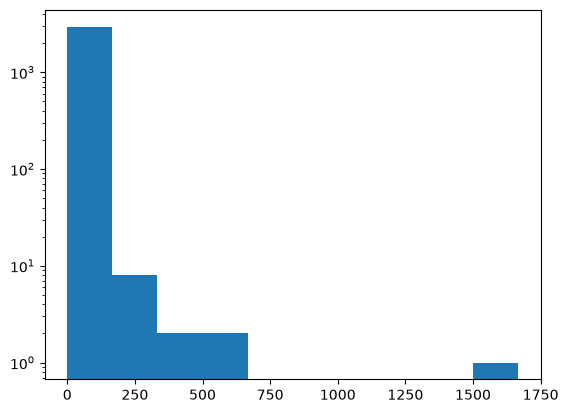

In [1394]:
plt.hist(list(degree.values()))
plt.yscale('log')

In [1395]:
from collections import Counter

degree_value_counts = Counter(list(degree.values()))
total_nodes = len(degree.values())
degree_value_fraction = [
    count / total_nodes
    for (deg, count) in degree_value_counts.items()
    if deg < 100
]

In [1396]:
def power_func(x, a, gamma):
    return a * x ** (-gamma)

a: 1.0, gamma: 1.0


/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_10725/1519728738.py:2: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-gamma)
/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_10725/1778186663.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  (a, gamma), _ = curve_fit(power_func, x, y)


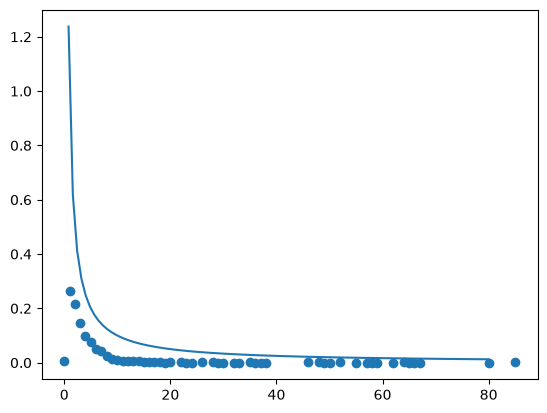

In [1397]:
from scipy.optimize import curve_fit

x, y = [deg for deg in degree_value_counts if deg < 100], degree_value_fraction

(a, gamma), _ = curve_fit(power_func, x, y)
print(f"a: {a}, gamma: {gamma}")

plt.scatter(x, y)
x = np.linspace(0, 80, 100)
plt.plot(x, power_func(x, a, gamma))

## First subgraph extraction strategy
Pick nodes not from the largest SCC, add in apt-order along with ancestors until N nodes have been added.

In [1398]:
sccs = sorted(list(nx.strongly_connected_components(g)), key=lambda x: len(x), reverse=True)
sccs[:5]

[{'acrR',
  'adiY',
  'arcA',
  'argP',
  'argR',
  'bglJ',
  'bolA',
  'cpxR',
  'cra',
  'crp',
  'csgD',
  'cspA',
  'csrA',
  'cytR',
  'deaD',
  'dksA',
  'dnaA',
  'evgA',
  'fis',
  'flhC',
  'flhD',
  'fliA',
  'fliZ',
  'fnr',
  'fur',
  'gadE',
  'gadW',
  'gadX',
  'glnG',
  'hdfR',
  'hns',
  'ihfA',
  'ihfB',
  'leuO',
  'lexA',
  'lldR',
  'lrhA',
  'lrp',
  'matA',
  'mlrA',
  'mqsA',
  'nac',
  'ompR',
  'oxyR',
  'phoB',
  'phoP',
  'qseB',
  'rcsA',
  'rcsB',
  'rpoD',
  'rpoE',
  'rpoH',
  'rpoN',
  'rpoS',
  'rpsA',
  'rstA',
  'rutR',
  'sdiA',
  'slyA',
  'soxR',
  'soxS',
  'stpA',
  'sutR',
  'torR',
  'ydeO',
  'ydiP',
  'yjjQ',
  'zraR'},
 {'marA', 'marR', 'rob'},
 {'accA', 'accD'},
 {'gutM', 'srlR'},
 {'dinJ', 'yafQ'}]

In [1399]:
len(sccs[0]), len(sccs[1])

(68, 3)

In [1400]:
directed_edges = list(g.edges())
g_mixed = NxMixedGraph.from_edges(directed=directed_edges)

# precompute apt-order once for the full graph
apt_order = [node.name for node in get_apt_order(g_mixed)]
apt_order

['glaR',
 'yiaU',
 'envR',
 'ulaR',
 'ycjW',
 'modE',
 'yidZ',
 'ptrR',
 'nsrR',
 'rcdA',
 'basR',
 'ygbI',
 'yhaJ',
 'cueR',
 'pgrR',
 'dicF',
 'hypT',
 'birA',
 'glrR',
 'nanR',
 'gatR',
 'nadR',
 'deoR',
 'racR',
 'yfeC',
 'kdpE',
 'btsR',
 'frmR',
 'envY',
 'fabR',
 'fimZ',
 'zur',
 'atoC',
 'ebgR',
 'citR',
 'alpA',
 'rclR',
 'ameF',
 'yrdG',
 'dicD',
 'ralA',
 'c0293',
 'selB',
 'nimR',
 'srmB',
 'punR',
 'pyrR',
 'yodB',
 'yfcV',
 'elfC',
 'yjdP',
 'ycgY',
 'ycbU',
 'yfjD',
 'ycbV',
 'rsgA',
 'orn',
 'ynaE',
 'yciU',
 'yfbO',
 'yehD',
 'priC',
 'yfbU',
 'yigG',
 'kdgT',
 'rhsD',
 'mrdA',
 'yjfY',
 'yidB',
 'yehS',
 'ydfI',
 'ypdC',
 'yihM',
 'hxpA',
 'yfdC',
 'bdcR',
 'yadN',
 'yfbN',
 'hinT',
 'ydhS',
 'yqhC',
 'ypjA',
 'smg',
 'yccU',
 'adeP',
 'yiaV',
 'yiaW',
 'yiaT',
 'ycjP',
 'ycjR',
 'ycjU',
 'ycjN',
 'ycjM',
 'ycjT',
 'ompG',
 'ycjO',
 'ycjV',
 'ycjQ',
 'ycjS',
 'ppiC',
 'yneG',
 'glsB',
 'norR',
 'tehA',
 'tehB',
 'ybjJ',
 'ybjI',
 'arnA',
 'arnB',
 'arnT',
 'dgkA',
 'a

In [1401]:
dec_from_scc = []
for node in list(sccs[0]):
    dec_from_scc.extend(nx.descendants(g, node) | {node})

dec_from_scc_set = set(dec_from_scc)

In [1402]:
len(apt_order)

2961

In [1403]:
len(dec_from_scc_set)

2822

In [1404]:
candidate_nodes_in_apt_order = list(set(apt_order) - dec_from_scc_set)  # Ignore largest SCCs for apt-ordering
# candidate_nodes_in_apt_order = list(set(apt_order) & (sccs[0] | dec_from_scc_set))  # Use largest SCCs

In [1405]:
total_nodes - len(candidate_nodes_in_apt_order)  # total nodes excluded from this subgraph

2837

In [1406]:
candidate_nodes_in_apt_order

['mrdA',
 'yhaK',
 'yehD',
 'ydaW',
 'glaR',
 'ypjA',
 'pliG',
 'deoR',
 'cueO',
 'smg',
 'ycjU',
 'arnF',
 'punR',
 'punC',
 'ycbU',
 'pnuC',
 'yigG',
 'atoC',
 'gatR',
 'intA',
 'btsR',
 'basR',
 'glrR',
 'glsB',
 'ycjO',
 'rclR',
 'ycjS',
 'racR',
 'ycjW',
 'yiaU',
 'tehA',
 'pyrR',
 'ycjM',
 'yidB',
 'yneG',
 'fimZ',
 'yiaV',
 'ynaE',
 'yihM',
 'dicD',
 'nanR',
 'yfeC',
 'envY',
 'yidZ',
 'ulaR',
 'ycjN',
 'yehS',
 'yqhC',
 'sfmA',
 'pgrR',
 'orn',
 'srmB',
 'sfmC',
 'birA',
 'yqjF',
 'norR',
 'yjdP',
 'rcdA',
 'ompG',
 'ycjV',
 'hxpA',
 'ycjR',
 'zur',
 'envR',
 'ybjJ',
 'arnA',
 'ralR',
 'rsgA',
 'arnC',
 'ydhS',
 'arnD',
 'ybjI',
 'yhaL',
 'kdgT',
 'hypT',
 'nimT',
 'nsrR',
 'rhsD',
 'arnT',
 'yfbU',
 'bdcR',
 'ppiC',
 'frmR',
 'ycgY',
 'ycbV',
 'ameF',
 'yfjD',
 'modE',
 'yiaT',
 'ypdC',
 'ydaS',
 'dgkA',
 'arnE',
 'yfbN',
 'priC',
 'yfbO',
 'yccU',
 'hinT',
 'dicA',
 'ygiD',
 'yfcV',
 'ycjG',
 'elfC',
 'alpA',
 'dicF',
 'ygbJ',
 'ycjP',
 'citR',
 'ptrR',
 'yodB',
 'nimR',
 'yj

In [1407]:
len(candidate_nodes_in_apt_order)

139

In [1408]:
N = 500

In [1409]:
subgraph_nodes = set()

In [1410]:
i = 0
while(len(subgraph_nodes) < N and i < len(candidate_nodes_in_apt_order)):
    node = candidate_nodes_in_apt_order[i]
    subgraph_nodes.add(node)
    ancestors = nx.ancestors(g, node)
    print(f"{len(ancestors)} ancestors for node {node}")
    for anc in nx.ancestors(g, node):
        subgraph_nodes.add(anc)
    i += 1

1 ancestors for node mrdA
1 ancestors for node yhaK
1 ancestors for node yehD
1 ancestors for node ydaW
0 ancestors for node glaR
1 ancestors for node ypjA
2 ancestors for node pliG
0 ancestors for node deoR
1 ancestors for node cueO
1 ancestors for node smg
1 ancestors for node ycjU
1 ancestors for node arnF
0 ancestors for node punR
1 ancestors for node punC
1 ancestors for node ycbU
1 ancestors for node pnuC
1 ancestors for node yigG
0 ancestors for node atoC
0 ancestors for node gatR
1 ancestors for node intA
0 ancestors for node btsR
0 ancestors for node basR
0 ancestors for node glrR
1 ancestors for node glsB
1 ancestors for node ycjO
0 ancestors for node rclR
1 ancestors for node ycjS
0 ancestors for node racR
0 ancestors for node ycjW
0 ancestors for node yiaU
2 ancestors for node tehA
0 ancestors for node pyrR
1 ancestors for node ycjM
1 ancestors for node yidB
1 ancestors for node yneG
0 ancestors for node fimZ
1 ancestors for node yiaV
1 ancestors for node ynaE
1 ancestors f

In [1411]:
i

139

In [1412]:
subgraph = g.subgraph(subgraph_nodes)

In [1413]:
subgraph = g.subgraph(
    [node for node in subgraph_nodes if g.subgraph(subgraph_nodes).degree(node) > 0]
).copy()

In [1414]:
print(len(subgraph.edges))
print(len(subgraph.nodes))

104
117


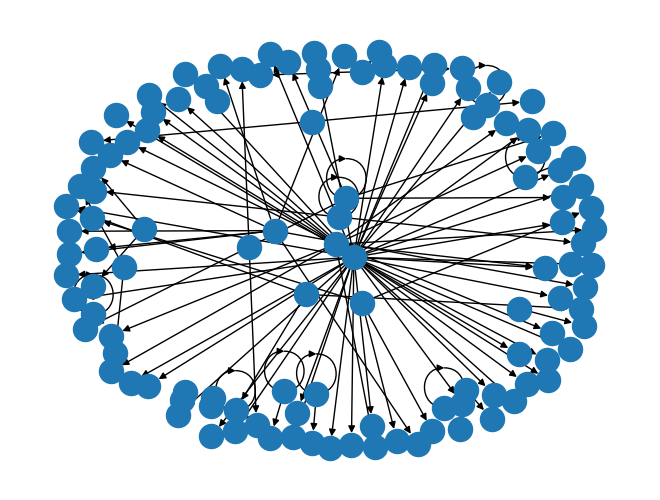

In [1415]:
nx.draw(subgraph)

In [1416]:
out_degree = dict(subgraph.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(subgraph.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(subgraph.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [1417]:
out_degree_list[:20]

[('glaR', 40),
 ('ycjW', 11),
 ('basR', 8),
 ('yhaJ', 5),
 ('yiaU', 4),
 ('racR', 3),
 ('rcdA', 3),
 ('nsrR', 3),
 ('fimZ', 2),
 ('pgrR', 2),
 ('frmR', 2),
 ('ptrR', 2),
 ('citR', 2),
 ('nimR', 2),
 ('nadR', 2),
 ('selB', 2),
 ('punR', 1),
 ('dicD', 1),
 ('yfeC', 1),
 ('yidZ', 1)]

In [1418]:
in_degree_list[:20]

[('pliG', 2),
 ('tehA', 2),
 ('norR', 2),
 ('dicA', 2),
 ('ycjP', 2),
 ('mrdA', 1),
 ('yhaK', 1),
 ('yehD', 1),
 ('ydaW', 1),
 ('ypjA', 1),
 ('cueO', 1),
 ('smg', 1),
 ('ycjU', 1),
 ('arnF', 1),
 ('punC', 1),
 ('ycbU', 1),
 ('pnuC', 1),
 ('yigG', 1),
 ('intA', 1),
 ('glsB', 1)]

In [1419]:
subgraph_sccs = sorted(list(nx.strongly_connected_components(subgraph)), key=lambda x: len(x), reverse=True)
subgraph_sccs

[{'mrdA'},
 {'yhaK'},
 {'yehD'},
 {'ydaW'},
 {'bdcR'},
 {'elfC'},
 {'hinT'},
 {'hxpA'},
 {'kdgT'},
 {'orn'},
 {'pliG'},
 {'priC'},
 {'rhsD'},
 {'rsgA'},
 {'smg'},
 {'tehA'},
 {'yadN'},
 {'ycbU'},
 {'ycbV'},
 {'yccU'},
 {'ycgY'},
 {'yciU'},
 {'ycjP'},
 {'ydfI'},
 {'ydhS'},
 {'yehS'},
 {'yfbN'},
 {'yfbO'},
 {'yfbU'},
 {'yfcV'},
 {'yfdC'},
 {'yfjD'},
 {'yidB'},
 {'yigG'},
 {'yihM'},
 {'yjdP'},
 {'yjfY'},
 {'ynaE'},
 {'yodB'},
 {'ypdC'},
 {'ypjA'},
 {'yqhC'},
 {'glaR'},
 {'cueO'},
 {'ycjU'},
 {'arnF'},
 {'punC'},
 {'punR'},
 {'pnuC'},
 {'intA'},
 {'arnA'},
 {'arnB'},
 {'arnC'},
 {'arnD'},
 {'arnE'},
 {'arnT'},
 {'dgkA'},
 {'basR'},
 {'glsB'},
 {'ycjO'},
 {'ycjS'},
 {'ydaS'},
 {'ydaV'},
 {'racR'},
 {'ompG'},
 {'ycjM'},
 {'ycjN'},
 {'ycjQ'},
 {'ycjR'},
 {'ycjT'},
 {'ycjV'},
 {'ycjW'},
 {'adeP'},
 {'yiaT'},
 {'yiaV'},
 {'yiaW'},
 {'yiaU'},
 {'yneG'},
 {'sfmA'},
 {'sfmC'},
 {'fimZ'},
 {'dicA'},
 {'dicD'},
 {'yfeC'},
 {'ppiC'},
 {'yidZ'},
 {'mppA'},
 {'ycjG'},
 {'pgrR'},
 {'yqjF'},
 {'norR'},
 

In [1420]:
degree_list[:20]

[('glaR', 40),
 ('ycjW', 11),
 ('basR', 8),
 ('yhaJ', 6),
 ('yiaU', 4),
 ('rcdA', 4),
 ('racR', 3),
 ('norR', 3),
 ('nsrR', 3),
 ('frmR', 3),
 ('dicA', 3),
 ('citR', 3),
 ('nimR', 3),
 ('selB', 3),
 ('pliG', 2),
 ('tehA', 2),
 ('fimZ', 2),
 ('yfeC', 2),
 ('pgrR', 2),
 ('ptrR', 2)]

(array([113.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1. ,  4.9,  8.8, 12.7, 16.6, 20.5, 24.4, 28.3, 32.2, 36.1, 40. ]),
 <BarContainer object of 10 artists>)

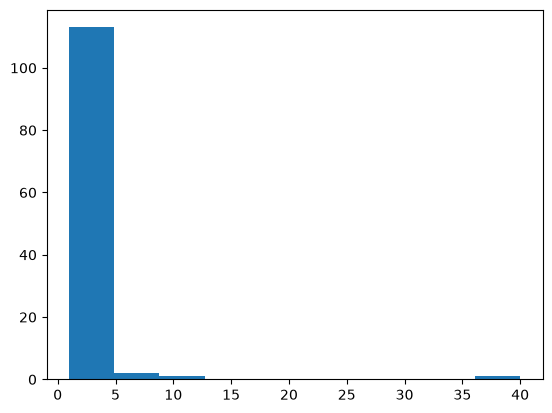

In [1421]:
plt.hist(list(degree.values()))

In [1422]:
from collections import Counter

degree_value_counts = Counter(list(degree.values()))
total_nodes = len(degree.values())
degree_value_fraction = [
    count / total_nodes
    for (deg, count) in degree_value_counts.items()
    if deg < 100
]

In [1423]:
def power_func(x, a, gamma):
    return a * x ** (-gamma)

a: 0.8110367947546101, gamma: 3.1736488314313993


/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_10725/1519728738.py:2: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-gamma)


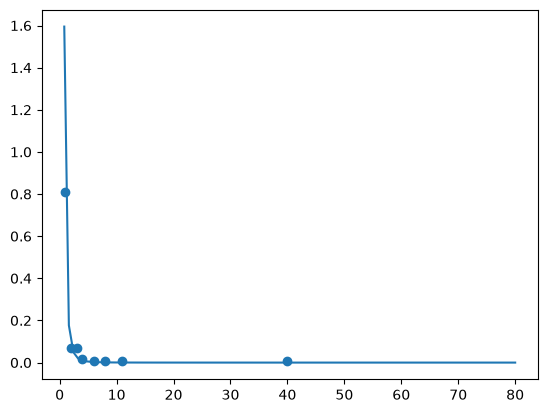

In [1424]:
from scipy.optimize import curve_fit

x, y = [deg for deg in degree_value_counts if deg < 100], degree_value_fraction

(a, gamma), _ = curve_fit(power_func, x, y)
print(f"a: {a}, gamma: {gamma}")

plt.scatter(x, y)
x = np.linspace(0, 80, 100)
plt.plot(x, power_func(x, a, gamma))

In [1425]:
from nocap.cyclic_single_door import classify_edge, nx_digraph_to_y0
from y0.algorithm.separation.sigma_extension import sigma_extension


precomputed_y0 = nx_digraph_to_y0(subgraph)
precomputed_extension = sigma_extension(precomputed_y0)

res = []

self_loop = 0

for (cause, effect) in subgraph.edges:
    if cause == effect:
        self_loop += 1
        continue
    adj_set = classify_edge(subgraph, cause, effect, precomputed_extension=precomputed_extension, precomputed_y0=precomputed_y0)
    res.append((cause, effect, adj_set))

In [1426]:
self_loop

9

In [1427]:
identifiable_edges = [r for r in res if r[2]['status'] == 'identifiable']
unidentifiable_edges = [r for r in res if r[2]['status'] == 'unidentifiable']
len(identifiable_edges), len(unidentifiable_edges)

(95, 0)

In [1428]:
sum(e[2]['same_scc'] for e in unidentifiable_edges)

0

In [1429]:
sum(len(e[2]['adjustment_set']) != 0 for e in identifiable_edges)

6

In [1430]:
identifiable_edges

[('glaR',
  'bdcR',
  {'cause': 'glaR',
   'effect': 'bdcR',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'elfC',
  {'cause': 'glaR',
   'effect': 'elfC',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'hinT',
  {'cause': 'glaR',
   'effect': 'hinT',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'hxpA',
  {'cause': 'glaR',
   'effect': 'hxpA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'kdgT',
  {'cause': 'glaR',
   'effect': 'kdgT',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'mrdA',
  {'cause': 'glaR',
   'effect': 'mrdA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False}),
 ('glaR',
  'orn',
  {'cause': 'glaR',
   'effect': 'orn',
   'status': 'identifiable',
   'adjustment_set': fro

In [1431]:
from nocap.cyclic_single_door import maximize_identifiable_edges

res = maximize_identifiable_edges(subgraph, k=3)

In [1432]:
res

{'curve': [(0, 95)],
 'chosen_nodes': [],
 'final_graph': <networkx.classes.digraph.DiGraph at 0x12ca51350>,
 'final_results': [{'cause': 'glaR',
   'effect': 'bdcR',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'glaR',
   'effect': 'elfC',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'glaR',
   'effect': 'hinT',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'glaR',
   'effect': 'hxpA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'glaR',
   'effect': 'kdgT',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'glaR',
   'effect': 'mrdA',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_scc': False},
  {'cause': 'glaR',
   'effect': 'orn',
   'status': 'identifiable',
   'adjustment_set': frozenset(),
   'same_

## Second subgraph extraction strategy
Pick N random edges from the graph, determine the adjustment sets for every edge and include those nodes. This ensures that causal effects can be recovered and also so no latent confounders are present for the identifiable edges.

In [1433]:
N=20

In [1434]:
# Randomly pick edges in the graph, calculate adjustment set and ensure that those nodes are present
random.seed(142)
random_edges = random.sample(sorted(g.edges), k=N)

In [1435]:
candidate_nodes = []

In [1436]:
precomputed_y0 = nx_digraph_to_y0(g)
precomputed_extension = sigma_extension(precomputed_y0)

self_loop = 0
for (node1, node2) in random_edges:
    if cause == effect:
        self_loop += 1
        continue
    adj_set = classify_edge(g, cause, effect, precomputed_extension=precomputed_extension, precomputed_y0=precomputed_y0)
    candidate_nodes.extend([node1, node2, *adj_set['adjustment_set']])

print(f"{self_loop} self loops")

0 self loops


In [1437]:
candidate_nodes_set = set(candidate_nodes)
candidate_nodes_set

{'cpxR',
 'dinJ',
 'dksA',
 'fecE',
 'flhC',
 'fur',
 'hns',
 'lexA',
 'lrp',
 'marA',
 'mdtA',
 'modE',
 'mqo',
 'nac',
 'napC',
 'nhaR',
 'ompR',
 'patA',
 'phoB',
 'prpR',
 'pstB',
 'rclA',
 'rpmG',
 'rpoD',
 'rpoE',
 'rpoS',
 'rpsU',
 'rseC',
 'slyA',
 'umuC',
 'ybhL',
 'yfeC',
 'ygaV'}

In [1438]:
len(candidate_nodes_set)

33

In [1439]:
subgraph = nx.subgraph(g, candidate_nodes)

In [1440]:
len(subgraph.nodes), len(subgraph.edges)

(33, 85)

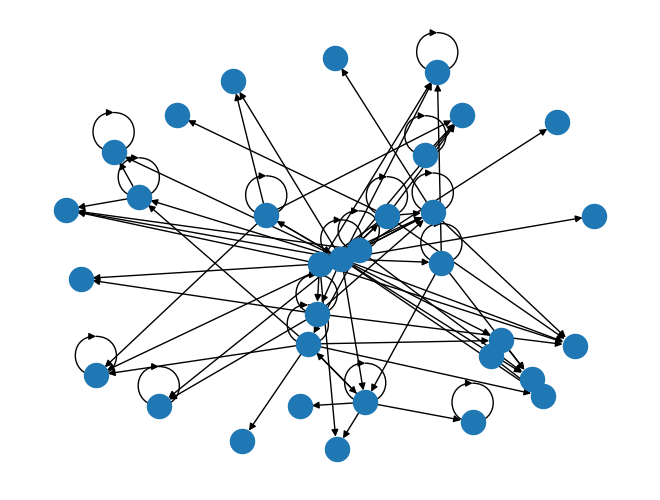

In [1441]:
nx.draw(subgraph)

In [1442]:
out_degree = dict(subgraph.out_degree)
out_degree_list = sorted(list(out_degree.items()), key=lambda x: x[1], reverse=True)
in_degree = dict(subgraph.in_degree)
in_degree_list = sorted(list(in_degree.items()), key=lambda x: x[1], reverse=True)
degree = dict(subgraph.degree)
degree_list = sorted(list(degree.items()), key=lambda x: x[1], reverse=True)

In [1443]:
out_degree_list[:20]

[('rpoD', 22),
 ('rpoS', 7),
 ('dksA', 7),
 ('nac', 7),
 ('fur', 6),
 ('cpxR', 5),
 ('lrp', 5),
 ('lexA', 5),
 ('hns', 4),
 ('rpoE', 4),
 ('phoB', 3),
 ('yfeC', 2),
 ('nhaR', 1),
 ('flhC', 1),
 ('prpR', 1),
 ('ompR', 1),
 ('modE', 1),
 ('slyA', 1),
 ('marA', 1),
 ('dinJ', 1)]

In [1444]:
in_degree_list[:20]

[('rseC', 5),
 ('rpoE', 5),
 ('pstB', 4),
 ('nhaR', 4),
 ('flhC', 4),
 ('lrp', 4),
 ('rpoD', 4),
 ('napC', 4),
 ('rpsU', 4),
 ('dinJ', 4),
 ('cpxR', 3),
 ('phoB', 3),
 ('prpR', 3),
 ('rpoS', 3),
 ('marA', 3),
 ('nac', 3),
 ('patA', 2),
 ('ompR', 2),
 ('hns', 2),
 ('dksA', 2)]

In [1445]:
subgraph_sccs = sorted(list(nx.strongly_connected_components(subgraph)), key=lambda x: len(x), reverse=True)
subgraph_sccs

[{'cpxR', 'dksA', 'fur', 'lexA', 'rpoD', 'rpoE', 'rpoS'},
 {'lrp', 'nac'},
 {'pstB'},
 {'nhaR'},
 {'napC'},
 {'flhC'},
 {'marA'},
 {'mdtA'},
 {'rclA'},
 {'dinJ'},
 {'rpmG'},
 {'patA'},
 {'rseC'},
 {'rpsU'},
 {'fecE'},
 {'mqo'},
 {'slyA'},
 {'ompR'},
 {'prpR'},
 {'phoB'},
 {'ygaV'},
 {'hns'},
 {'umuC'},
 {'ybhL'},
 {'yfeC'},
 {'modE'}]

In [1446]:
degree_list[:20]

[('rpoD', 26),
 ('rpoS', 10),
 ('nac', 10),
 ('lrp', 9),
 ('dksA', 9),
 ('rpoE', 9),
 ('cpxR', 8),
 ('fur', 8),
 ('lexA', 7),
 ('phoB', 6),
 ('hns', 6),
 ('nhaR', 5),
 ('flhC', 5),
 ('rseC', 5),
 ('dinJ', 5),
 ('pstB', 4),
 ('prpR', 4),
 ('napC', 4),
 ('marA', 4),
 ('rpsU', 4)]

(array([13.,  9.,  5.,  5.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 1. ,  3.5,  6. ,  8.5, 11. , 13.5, 16. , 18.5, 21. , 23.5, 26. ]),
 <BarContainer object of 10 artists>)

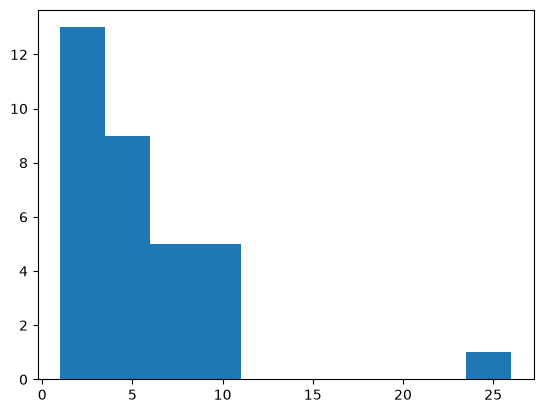

In [1447]:
plt.hist(list(degree.values()))

In [1448]:
degree.values()

dict_values([4, 5, 5, 8, 1, 2, 6, 4, 10, 3, 1, 9, 1, 3, 6, 9, 5, 26, 2, 4, 1, 1, 1, 1, 3, 4, 10, 7, 4, 8, 5, 2, 9])

In [1449]:
from collections import Counter

degree_value_counts = Counter(list(degree.values()))
total_nodes = len(degree.values())
degree_value_fraction = [
    count / total_nodes
    for (deg, count) in degree_value_counts.items()
    if deg < 100
]

In [1450]:
def power_func(x, a, gamma):
    return a * x ** (-gamma)

a: 0.1961789752579976, gamma: 0.5188563300231102


/var/folders/fh/s3jslwf92j51vj6gd_4hdsh80000gp/T/ipykernel_10725/1519728738.py:2: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-gamma)


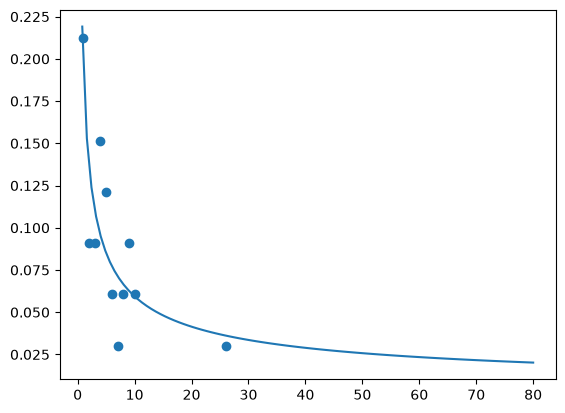

In [1451]:
from scipy.optimize import curve_fit

x, y = [deg for deg in degree_value_counts if deg < 100], degree_value_fraction

(a, gamma), _ = curve_fit(power_func, x, y)
print(f"a: {a}, gamma: {gamma}")

plt.scatter(x, y)
x = np.linspace(0, 80, 100)
plt.plot(x, power_func(x, a, gamma))

In [1452]:
from nocap.cyclic_single_door import classify_edge, nx_digraph_to_y0
from y0.algorithm.separation.sigma_extension import sigma_extension


precomputed_y0 = nx_digraph_to_y0(subgraph)
precomputed_extension = sigma_extension(precomputed_y0)

res = []

self_loop = 0

for (cause, effect) in subgraph.edges:
    if cause == effect:
        self_loop += 1
        continue
    adj_set = classify_edge(subgraph, cause, effect, precomputed_extension=precomputed_extension, precomputed_y0=precomputed_y0)
    res.append((cause, effect, adj_set))

In [1453]:
self_loop

16

In [1454]:
identifiable_edges = [r for r in res if r[2]['status'] == 'identifiable']
unidentifiable_edges = [r for r in res if r[2]['status'] == 'unidentifiable']
len(identifiable_edges), len(unidentifiable_edges)

(52, 17)

In [1455]:
sum(e[2]['same_scc'] for e in unidentifiable_edges)

17

In [1456]:
sum(len(e[2]['adjustment_set']) != 0 for e in identifiable_edges)

52

In [1457]:
identifiable_edges

[('flhC',
  'napC',
  {'cause': 'flhC',
   'effect': 'napC',
   'status': 'identifiable',
   'adjustment_set': frozenset({'fur', 'hns', 'modE', 'nac', 'ompR', 'rpoD'}),
   'same_scc': False}),
 ('cpxR',
  'marA',
  {'cause': 'cpxR',
   'effect': 'marA',
   'status': 'identifiable',
   'adjustment_set': frozenset({'dksA',
              'fur',
              'lexA',
              'rpoD',
              'rpoE',
              'rpoS'}),
   'same_scc': False}),
 ('cpxR',
  'mdtA',
  {'cause': 'cpxR',
   'effect': 'mdtA',
   'status': 'identifiable',
   'adjustment_set': frozenset({'dksA',
              'fur',
              'lexA',
              'rpoD',
              'rpoE',
              'rpoS'}),
   'same_scc': False}),
 ('cpxR',
  'rseC',
  {'cause': 'cpxR',
   'effect': 'rseC',
   'status': 'identifiable',
   'adjustment_set': frozenset({'dksA',
              'fur',
              'lexA',
              'rpoD',
              'rpoE',
              'rpoS'}),
   'same_scc': False}),
 ('phoB',
  

In [1458]:
from nocap.cyclic_single_door import maximize_identifiable_edges

res = maximize_identifiable_edges(subgraph, k=3)
res

{'curve': [(0, 52), (1, 64)],
 'chosen_nodes': ['rpoD'],
 'final_graph': <networkx.classes.digraph.DiGraph at 0x12ca528b0>,
 'final_results': [{'cause': 'nhaR',
   'effect': 'nhaR',
   'status': 'unidentifiable',
   'adjustment_set': None,
   'same_scc': True},
  {'cause': 'flhC',
   'effect': 'napC',
   'status': 'identifiable',
   'adjustment_set': frozenset({'fur', 'hns', 'modE', 'nac', 'ompR', 'rpoD'}),
   'same_scc': False},
  {'cause': 'cpxR',
   'effect': 'cpxR',
   'status': 'unidentifiable',
   'adjustment_set': None,
   'same_scc': True},
  {'cause': 'cpxR',
   'effect': 'marA',
   'status': 'identifiable',
   'adjustment_set': frozenset({'rpoD', 'rpoS'}),
   'same_scc': False},
  {'cause': 'cpxR',
   'effect': 'mdtA',
   'status': 'identifiable',
   'adjustment_set': frozenset({'rpoD', 'rpoS'}),
   'same_scc': False},
  {'cause': 'cpxR',
   'effect': 'rpoE',
   'status': 'identifiable',
   'adjustment_set': frozenset({'dksA', 'rpoD', 'rpoS'}),
   'same_scc': False},
  {'caus